# Thermal Gradient Figures

TODO:
1. transmission w mux, both peltiers from 50 ->10. 5 degree change every 5 min. Must be stable (within 0.5 deg of target) for at least 1 min.  (~2hr)
2. transmission w mux, starting with 30 +- 0. 1 degree change every 3 min. Must be stable (within 0.5 deg of target) for at least 1 min. (~90 min)

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonicTesting/')

import pickleJar as pj
import sqliteUtils as squ
import numpy as np
from numpy import fft
import os.path
import matplotlib.pyplot as plt

import ipywidgets

# 1. average temperature

In [2]:
# First we load the data from the file we want to analyze
# The experiment should always output sqlite3 files, so let's convert them to a more usable pickle form first
sqliteFile = '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/lmfp_cu_mux_gradient1782763514.sqlite3'
# Convert the sqlite3 to a .pickle
# This takes a few seconds. A progress bar will display in your terminal
pj.sqliteToPickle(sqliteFile)

# Load the pickle
pickleFile = os.path.splitext(sqliteFile)[0] + '.pickle'

data = pj.loadPickle(pickleFile)
data['parameters']['dt'] = data['parameters']['measureTime']-data['parameters']['measureDelay'] *10-6/ data['parameters']['samples']

sqliteToPickle Warning: pickle file /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/lmfp_cu_mux_gradient1782763514.pickle already exists. Conversion aborted.


In [3]:
data['parameters']

{'gui': 0.0,
 'experiment': 'repeat pulse',
 'axis': 'x',
 'distance': -50.0,
 'transducerFrequency': 2.25,
 'collectionMode': 'transmission',
 'pulserType': 'standard',
 'measureTime': 7.75,
 'measureDelay': 2.0,
 'voltageRange': 2.0,
 'autoRange': 'True',
 'autoRangeEcho': 'False',
 'waves': 100.0,
 'samples': 2500.0,
 'halfCycles': 2.0,
 'multiplexer': 'True',
 'collectionDirection': 'both',
 'voltageOffsetForward': 0.0,
 'voltageOffsetReverse': 0.0,
 'gainForward': 500.0,
 'gainReverse': 500.0,
 'picoModule': 1.0,
 'pulseModule': 0.0,
 'rfSwitch': 2.0,
 't0PulseSwitch': 0.0,
 't0ReceiveSwitch': 0.0,
 't1PulseSwitch': 1.0,
 't1ReceiveSwitch': 1.0,
 'experimentFolder': 'C://Users//changlab//Desktop//UT Data//temperature testing//',
 'experimentName': 'lmfp_cu_mux_gradient',
 'experimentBaseName': 'test_multiscan_data',
 'saveFormat': 'sqlite',
 'postAnalysis': 'False',
 'primaryAxis': 'X',
 'secondaryAxis': 'Z',
 'primaryAxisRange': 180.0,
 'primaryAxisStep': 2.0,
 'secondaryAxisRang

In [4]:
data[0].keys()

dict_keys(['voltage_transmission_forward', 'voltage_transmission_reverse', 'time', 'time_collected', 'collection_index'])

In [5]:
data['dt'] = (data['parameters']['measureTime']-data['parameters']['measureDelay'])/data['parameters']['samples']
data['dt']

0.0023

## Merge the waveform and controller data wrt time that UT is running

In [6]:
def correct_voltage(dataframe_col):
    '''correct measurements by matching mean of 1st 25 pts to 0.
    '''
    for item in dataframe_col:
        item -= item[:25].mean()
    return dataframe_col

In [7]:
import pandas as pd
measurements = {k:v for k,v in data.items() if isinstance(k, int)}
waveform_df = pd.DataFrame(measurements).transpose()
waveform_df['voltage_transmission_forward'] = correct_voltage(waveform_df['voltage_transmission_forward'])
waveform_df['voltage_transmission_reverse'] = correct_voltage(waveform_df['voltage_transmission_reverse'])
waveform_df

,voltage_transmission_forward,voltage_transmission_reverse,time,time_collected,collection_index
0,"[0.4079478346456695, 0.4943774606299214, -0.71...","[-0.5808070866141735, -0.062229330708661657, -...","[2000.0, 2002.0, 2004.0, 2006.0, 2008.0, 2010....",1782763514.931553,0.0
1,"[-0.45757874015748, -0.4569635826771652, 0.582...","[-0.3768331692913387, -0.2904035433070866, 0.0...","[2000.0, 2002.0, 2004.0, 2006.0, 2008.0, 2010....",1782763515.63551,1.0
2,"[0.08047490157480652, 0.33853346456693245, 0.4...","[0.09334399606299204, 0.179773622047244, -0.16...","[2000.0, 2002.0, 2004.0, 2006.0, 2008.0, 2010....",1782763516.642991,2.0
3,"[-0.054970472440949436, -0.2296751968503976, 0...","[-0.058772145669291564, 0.027657480314960514, ...","[2000.0, 2002.0, 2004.0, 2006.0, 2008.0, 2010....",1782763517.698947,3.0
4,"[-0.0304256889763721, -0.11839320866141279, 0....","[0.31806102362204725, -0.3733759842519686, 0.1...","[2000.0, 2002.0, 2004.0, 2006.0, 2008.0, 2010....",1782763518.663779,4.0
...,...,...,...,...,...
2026,"[-0.5356914370078734, -0.10215920275590307, -0...","[-0.057388041338582774, 0.33185285433070844, -...","[2000.0, 2002.0, 2004.0, 2006.0, 2008.0, 2010....",1782765542.556117,2026.0
2027,"[0.12319758858267704, -0.4835014763779526, 0.0...","[-0.1642593503937002, -0.07782972440944835, -0...","[2000.0, 2002.0, 2004.0, 2006.0, 2008.0, 2010....",1782765543.565948,2027.0
2028,"[0.24070497047243933, 0.024784694881887503, 0....","[-0.13640501968503926, -0.007068159448818889, ...","[2000.0, 2002.0, 2004.0, 2006.0, 2008.0, 2010....",1782765544.558933,2028.0
2029,"[0.28427657480315105, -0.27890009842519703, -0...","[0.1003014271653555, 0.056932824803149984, 0.0...","[2000.0, 2002.0, 2004.0, 2006.0, 2008.0, 2010....",1782765545.565428,2029.0


In [8]:
## Read in monitor data, add ms to time
from datetime import datetime

monitor_file_path = '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/CoSo_2026-06-29_16-39-27_Monitor.csv'
settings_file_path = '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/CoSo_2026-06-29_16-39-27_Settings.csv'

controller_monitor_df = pd.read_csv(monitor_file_path,
                            delimiter=';',
                            usecols=[   'Time', 'Milliseconds',
                                        '1000.1: CH1 Object', '1000.2: CH2 Object', # ###.#: is the firmware output for that channel.
                                        '1001.1: CH1 Sink', '1001.2: CH2 Sink',
                                        '1045.1: HR1 Temp', '1045.2: HR2 Temp',
                                        '1044.1: LR1 Temp', '1044.2: LR2 Temp',
                                        '3000.1: CH1 Target', '3000.2: CH2 Target',
                                    ])
controller_monitor_df['Time_str'] = controller_monitor_df['Time']
controller_monitor_df['Time'] = controller_monitor_df['Time'].apply(lambda x: datetime.strptime(x, '%m/%d/%Y %I:%M:%S %p').timestamp())
controller_monitor_df['Time'] += controller_monitor_df['Milliseconds']/1000
controller_monitor_df.drop(columns=['Milliseconds'], inplace=True)

## Read in settings data, add ms to time
controller_settings_df = pd.read_csv(settings_file_path,
                            delimiter=';',
                            usecols=[   'Time', 'Milliseconds',
                                        '2010.1: Output Enable', '2010.2: Output Enable', 
                                        '3034.1: Peltier Polarity', '3034.2: Peltier Polarity',
                                        '1200.1: Temperature is Stable','1200.2: Temperature is Stable'
                                    ])

# to correct later: PID params, max temperature change, )
controller_settings_df['Time'] = controller_settings_df['Time'].apply(lambda x: datetime.strptime(x, '%m/%d/%Y %I:%M:%S %p').timestamp())
controller_settings_df['Time'] += controller_settings_df['Milliseconds']/1000
controller_settings_df.drop(columns=['Milliseconds'], inplace=True)

## Merge monitor and settings data
controller_df = pd.merge_asof(
    left=controller_monitor_df,
    right=controller_settings_df,
    left_on='Time',
    right_on='Time',
    direction='nearest' 
)
## Convert time to float in all dfs
waveform_df['time_collected'] = waveform_df['time_collected'].astype(float)
controller_monitor_df['Time'] = controller_monitor_df['Time'].astype(float)
controller_settings_df['Time'] = controller_settings_df['Time'].astype(float)

## Merge waveform and controller data
merged_df = pd.merge_asof(
    left=waveform_df,
    right=controller_df,
    left_on='time_collected',
    right_on='Time',
    direction='nearest' 
)
## reformat time Time_str to '%m/%d/%y %H:%M:%S'
merged_df['Time_str'] = pd.to_datetime(merged_df['Time_str']).dt.strftime('%m/%d/%y %H:%M:%S')
merged_df.to_csv('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/merged_df.csv')

/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_42321/930824303.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['Time_str'] = pd.to_datetime(merged_df['Time_str']).dt.strftime('%m/%d/%y %H:%M:%S')


In [9]:
merged_df.tail()

,voltage_transmission_forward,voltage_transmission_reverse,time,time_collected,collection_index,Time,1000.1: CH1 Object,1000.2: CH2 Object,1001.1: CH1 Sink,1001.2: CH2 Sink,...,1045.2: HR2 Temp,3000.1: CH1 Target,3000.2: CH2 Target,Time_str,1200.1: Temperature is Stable,1200.2: Temperature is Stable,2010.1: Output Enable,2010.2: Output Enable,3034.1: Peltier Polarity,3034.2: Peltier Polarity
2026,"[-0.5356914370078734, -0.10215920275590307, -0...","[-0.057388041338582774, 0.33185285433070844, -...","[2000.0, 2002.0, 2004.0, 2006.0, 2008.0, 2010....",1.782766e+09,2026.0,1.782766e+09,40.912315,20.965601,21.441370,33.098228,...,20.965601,41.0,19.0,06/29/26 16:39:02,2,1,OFF,ON,Cooling,Cooling
2027,"[0.12319758858267704, -0.4835014763779526, 0.0...","[-0.1642593503937002, -0.07782972440944835, -0...","[2000.0, 2002.0, 2004.0, 2006.0, 2008.0, 2010....",1.782766e+09,2027.0,1.782766e+09,40.922081,21.147058,21.490076,33.348625,...,21.147058,41.0,19.0,06/29/26 16:39:03,2,1,OFF,ON,Cooling,Cooling
2028,"[0.24070497047243933, 0.024784694881887503, 0....","[-0.13640501968503926, -0.007068159448818889, ...","[2000.0, 2002.0, 2004.0, 2006.0, 2008.0, 2010....",1.782766e+09,2028.0,1.782766e+09,40.257500,21.509150,21.578272,33.794640,...,21.509150,41.0,19.0,06/29/26 16:39:04,0,1,OFF,OFF,Cooling,Cooling
2029,"[0.28427657480315105, -0.27890009842519703, -0...","[0.1003014271653555, 0.056932824803149984, 0.0...","[2000.0, 2002.0, 2004.0, 2006.0, 2008.0, 2010....",1.782766e+09,2029.0,1.782766e+09,39.263481,21.963800,21.641718,34.062523,...,21.963800,41.0,19.0,06/29/26 16:39:05,0,1,OFF,OFF,Cooling,Cooling
2030,"[0.19904035433070533, 0.06924212598424972, 0.0...","[-0.2285925196850398, -0.05496432086614167, -0...","[2000.0, 2002.0, 2004.0, 2006.0, 2008.0, 2010....",1.782766e+09,2030.0,1.782766e+09,37.803429,23.848932,21.711267,34.411552,...,23.848932,41.0,19.0,06/29/26 16:39:07,0,1,OFF,OFF,Cooling,Cooling


## Compare Curves of gradients vs means

In [10]:
merged_df['index'] = merged_df.index
merged_df['means'] = merged_df[['1000.1: CH1 Object', '1000.2: CH2 Object']].mean(axis=1)
merged_df['diff'] = merged_df['1000.2: CH2 Object'] - merged_df['1000.1: CH1 Object']

for key_ in ['_forward', '_reverse']:    
    merged_df['amplitude'+key_] = list(map(pj.maxMinusMin, merged_df['voltage_transmission'+key_]))
    merged_df['Simple ToF'+key_] = list(map(pj.simpleThresholdTOF, merged_df['voltage_transmission'+key_], merged_df['time'], [0.1,] * len(merged_df)))
    merged_df['Hilbert ToF'+key_] = list(map(pj.envelopeThresholdTOF, merged_df['voltage_transmission'+key_], merged_df['time'], [0.1,] * len(merged_df)))

In [11]:
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from datetime import datetime
import matplotlib.cm as cm

def plot_waveform(i):
    plt.figure(figsize=(8, 4))
               
    plt.plot(merged_df['time'][i], merged_df['voltage_transmission_forward'][i], lw=1, label='forward')
    plt.vlines(merged_df['Simple ToF_forward'][i], -550, 550, color='red', lw=1, linestyles='--', label='Simple ToF forward')
    plt.vlines(merged_df['Hilbert ToF_forward'][i], -550, 550, color='blue', lw=1, linestyles='--', label='Hilbert ToF forward')
    
    plt.plot(merged_df['time'][i], merged_df['voltage_transmission_reverse'][i], lw=1, label='reverse')
    plt.vlines(merged_df['Simple ToF_reverse'][i], -550, 550, color='orange', lw=1, linestyles='--', label='Simple ToF reverse')
    plt.vlines(merged_df['Hilbert ToF_reverse'][i], -550, 550, color='green', lw=1, linestyles='--', label='Hilbert ToF reverse')
    
    
    plt.title(f'Measurement {i} at ({merged_df["Time_str"][i]})')
    plt.ylim(-550, 550)
    plt.xlabel('Time (ns)')
    plt.ylabel('Voltage (mV)')
    plt.legend()
    plt.tight_layout()
    plt.show()

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(merged_df)-1,
    step=1,
    description='measurement:',
    continuous_update=False
)

interact(plot_waveform, i=slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='measurement:', max=2030), Outpu…

<function __main__.plot_waveform(i)>

In [12]:
def plot_temps(i):
    xticks_labels = merged_df['index'].astype(str) + ': ' + merged_df['Time_str']

    plt.figure(figsize=(8, 6))
    # plt.plot(xticks_labels, merged_df['diff'], label='difference')
    plt.plot(xticks_labels, merged_df['means'], label='mean')
    lower_bound = merged_df['means'] - merged_df['diff'] / 2
    plt.plot(xticks_labels, lower_bound, label='transmitter side temperature', linewidth=1, linestyle='--')
    upper_bound = merged_df['means'] + merged_df['diff'] / 2
    plt.plot(xticks_labels, upper_bound, label='receiver side temperature', linewidth=1, linestyle='--')
    plt.fill_between(
        xticks_labels,
        lower_bound,
        upper_bound,  # Upper half
        alpha=0.25,
        )

    plt.vlines(xticks_labels[i], 0, 60, color='red', lw=1, linestyles='--', label='current measurement')
    plt.title(f'Temperature gradient throughout experiment, {i}')
    plt.xlabel('Time')
    plt.ylabel('Temperature (C)')
    plt.legend()
    plt.ylim(0, 60)
    plt.xticks(ticks=range(0, len(xticks_labels), max(1, len(xticks_labels)//15)), labels=xticks_labels[::max(1, len(xticks_labels)//15)], rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
   
    
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(merged_df)-1,
    step=1,
    description='measurement:',
    continuous_update=False
)

interact(plot_temps, i=slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='measurement:', max=2030), Outpu…

<function __main__.plot_temps(i)>

## Filter out outliers (+/- 5 from target)

In [13]:
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from datetime import datetime

mask = ( (merged_df['1000.1: CH1 Object'] - merged_df['3000.1: CH1 Target']).abs() < 0.25  
   ) & ( (merged_df['1000.2: CH2 Object'] - merged_df['3000.2: CH2 Target']).abs() < 0.25 )

merged_filtered_df = merged_df.loc[mask].copy().reset_index(drop=True)
xticks_labels = merged_filtered_df['index'].astype(str) + ': ' + merged_filtered_df['Time_str']

In [14]:
def plot_temps(i):
    plt.figure(figsize=(8, 6))
    # plt.plot(xticks_labels, merged_df['diff'], label='difference')
    plt.plot(xticks_labels, merged_filtered_df['means'], label='mean')
    lower_bound = merged_filtered_df['means'] - merged_filtered_df['diff'] / 2
    plt.plot(xticks_labels, lower_bound, label='transmitter side temperature', linewidth=1, linestyle='--')
    upper_bound = merged_filtered_df['means'] + merged_filtered_df['diff'] / 2
    plt.plot(xticks_labels, upper_bound, label='receiver side temperature', linewidth=1, linestyle='--')
    plt.fill_between(
        xticks_labels,
        lower_bound,
        upper_bound,  # Upper half
        alpha=0.25,
        )

    plt.vlines(xticks_labels[i], 0, 60, color='red', lw=1, linestyles='--', label='current measurement')
    plt.title(f'Temperature gradient throughout experiment, {i}')
    plt.xlabel('Time')
    plt.ylabel('Temperature (C)')
    plt.legend()
    plt.ylim(0, 60)
    plt.xticks(ticks=range(0, len(xticks_labels), max(1, len(xticks_labels)//15)), labels=xticks_labels[::max(1, len(xticks_labels)//15)], rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
   
    
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(merged_filtered_df)-1,
    step=1,
    description='measurement:',
    continuous_update=False
)

interact(plot_temps, i=slider)

interactive(children=(IntSlider(value=0, continuous_update=False, description='measurement:', max=1381), Outpu…

<function __main__.plot_temps(i)>

## tof and amplitudes

### avg

10
15
20
25
35
40
45
50


TypeError: expected x and y to have same length

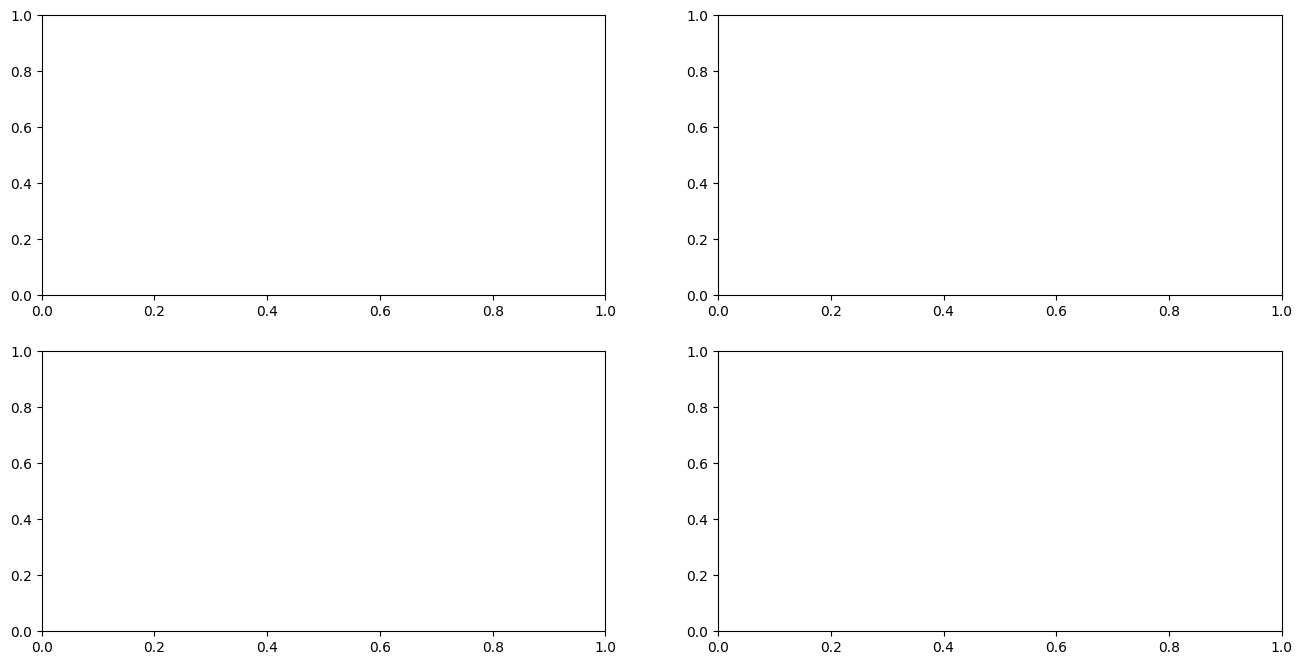

In [17]:
import matplotlib.pyplot as plt

temps = range(10,55,5)
f_time_arr, f_time_err = [], []
r_time_arr, r_time_err = [], []
f_amp_arr, f_amp_err = [], []
r_amp_arr, r_amp_err = [], []

for i in temps:
    mask =  (merged_filtered_df['3000.1: CH1 Target'] == i) & \
            (merged_filtered_df['3000.2: CH2 Target'] == i) & \
            (merged_filtered_df.index < 750)
    filtered_df = merged_filtered_df[mask]
    
    if filtered_df.empty: 
        print(i)
        continue
    
    f_time_arr.append(filtered_df[f'Simple ToF_forward'].mean())
    f_time_err.append(filtered_df[f'Simple ToF_forward'].std())
    
    r_time_arr.append(filtered_df[f'Simple ToF_reverse'].mean())
    r_time_err.append(filtered_df[f'Simple ToF_reverse'].std())
    
    f_amp_arr.append(filtered_df[f'amplitude_forward'].mean())
    f_amp_err.append(filtered_df[f'amplitude_forward'].std())
    
    r_amp_arr.append(filtered_df[f'amplitude_reverse'].mean())
    r_amp_err.append(filtered_df[f'amplitude_reverse'].std())
    

fig, ax = plt.subplots(2, 2, figsize=(16, 8))

f_m, f_b = np.polyfit(temps, f_time_arr, 1)
f_fit = f_m * np.array(temps) + f_b
ax[0, 0].plot(temps, f_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward ToF: {f_m:.2f}T + {f_b:.2f} (ns)')
ax[0, 0].errorbar(temps, f_time_arr, yerr=f_time_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f' Forward ToF: 1 StDv')
r_m, r_b = np.polyfit(temps, r_time_arr, 1)
r_fit = r_m * np.array(temps) + r_b
ax[0, 0].plot(temps, r_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse ToF: {r_m:.2f}T + {r_b:.2f} (ns)')
ax[0, 0].errorbar(temps, r_time_arr, yerr=r_time_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f' Reverse ToF: 1 StDv')
ax[0, 0].set_title('ToF: average temperature from 10-55ºC')
ax[0, 0].set_xlabel('T (ºC)')
ax[0, 0].set_ylabel('ToF (ns) Forward' )
ax[0, 0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

f_residuals = f_time_arr - f_fit
ax[0, 1].plot(temps, f_residuals, color='blue', linewidth=1, linestyle='--', label=f'Forward ToF: {f_m:.2f}T + {f_b:.2f} (ns)')
ax[0, 1].errorbar(temps, f_residuals, yerr=f_time_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f' Forward ToF: 1 StDv')
r_residuals = r_time_arr - r_fit
ax[0, 1].plot(temps, r_residuals, color='green', linewidth=1, linestyle='--', label=f'Reverse ToF: {r_m:.2f}T + {r_b:.2f} (ns)')
ax[0, 1].errorbar(temps, r_residuals, yerr=r_time_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f' Reverse ToF: 1 StDv')
ax[0, 1].set_title('ToF: fit residuals from 10-55ºC')
ax[0, 1].set_xlabel('T (ºC)')
ax[0, 1].set_ylabel('ToF (ns) Residuals')
ax[0, 1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

f_m, f_b = np.polyfit(temps, f_amp_arr, 1)
f_fit = f_m * np.array(temps) + f_b
ax[1,0].plot(temps, f_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward ToF: {f_m:.2f}T + {f_b:.2f} (ns)')
ax[1,0].errorbar(temps, f_amp_arr, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f' Forward Amplitude: 1 StDv')
r_m, r_b = np.polyfit(temps, r_amp_arr, 1)
r_fit = r_m * np.array(temps) + r_b
ax[1,0].plot(temps, r_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse ToF: {r_m:.2f}T + {r_b:.2f} (ns)')
ax[1,0].errorbar(temps, r_amp_arr, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f' Reverse Amplitude: 1 StDv')
ax[1,0].set_title('Peak to Peak Amplitude: average temperature from 10-55ºC')
ax[1,0].set_xlabel('T (ºC)')
ax[1,0].set_ylabel('Amplitude (mV)')
ax[1,0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

f_residuals = f_amp_arr - f_fit
ax[1,1].plot(temps, f_residuals, color='blue', linewidth=1, linestyle='--', label=f'Forward ToF: {f_m:.2f}T + {f_b:.2f} (ns)')
ax[1,1].errorbar(temps, f_residuals, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f' Forward Amplitude: 1 StDv')
r_residuals = r_amp_arr - r_fit
ax[1,1].plot(temps, r_residuals, color='green', linewidth=1, linestyle='--', label=f'Reverse ToF: {r_m:.2f}T + {r_b:.2f} (ns)')
ax[1,1].errorbar(temps, r_residuals, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f' Reverse Amplitude: 1 StDv')
ax[1,1].set_title('Peak to Peak Amplitude: average temperature from 10-55ºC')
ax[1,1].set_xlabel('T (ºC)')
ax[1,1].set_ylabel('Amplitude (mV)')
ax[1,1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

fig.tight_layout()

### dt

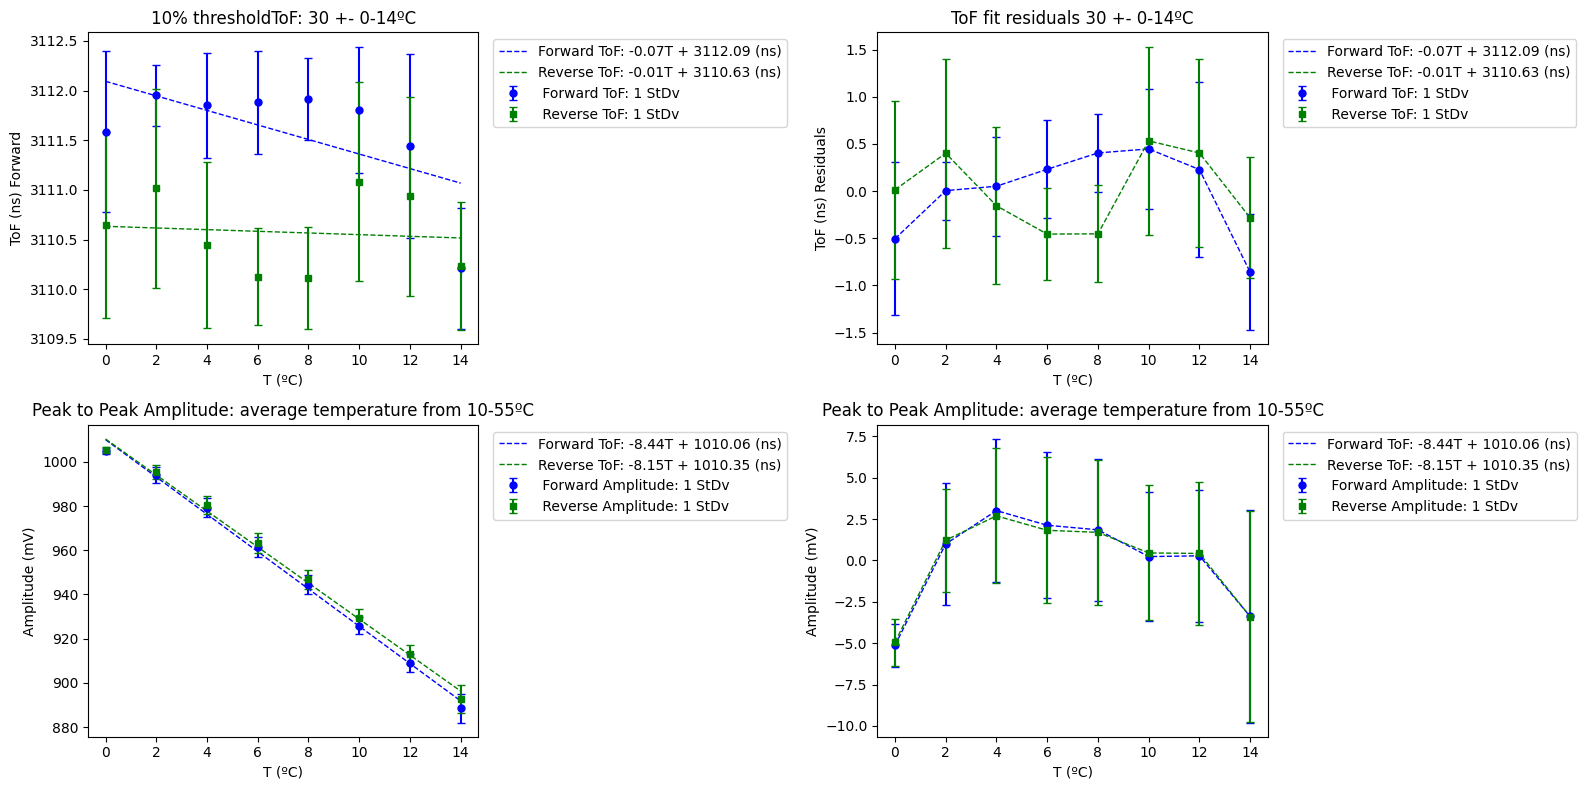

In [15]:
import matplotlib.pyplot as plt

d_temps = range(0, 16, 2)
f_time_arr, f_time_err = [], []
r_time_arr, r_time_err = [], []
f_amp_arr, f_amp_err = [], []
r_amp_arr, r_amp_err = [], []

for i in range(8):
    mask = (
        (merged_filtered_df['3000.1: CH1 Target'] == 30 + i)
        & (merged_filtered_df['3000.2: CH2 Target'] == 30 - i)
        & (merged_filtered_df['2010.1: Output Enable'] == 'ON')
        & (merged_filtered_df['2010.2: Output Enable'] == 'ON')
    )
    filtered_df = merged_filtered_df[mask]
    if filtered_df.empty: 
        print(i)
        continue
    
    f_time_arr.append(filtered_df[f'Simple ToF_forward'].mean())
    f_time_err.append(filtered_df[f'Simple ToF_forward'].std())

    r_time_arr.append(filtered_df[f'Simple ToF_reverse'].mean())
    r_time_err.append(filtered_df[f'Simple ToF_reverse'].std())
    
    f_amp_arr.append(filtered_df[f'amplitude_forward'].mean())
    f_amp_err.append(filtered_df[f'amplitude_forward'].std())
    
    r_amp_arr.append(filtered_df[f'amplitude_reverse'].mean())
    r_amp_err.append(filtered_df[f'amplitude_reverse'].std())
    

fig, ax = plt.subplots(2, 2, figsize=(16, 8))

f_m, f_b = np.polyfit(d_temps, f_time_arr, 1)
f_fit = f_m * np.array(d_temps) + f_b
ax[0, 0].plot(d_temps, f_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward ToF: {f_m:.2f}T + {f_b:.2f} (ns)')
ax[0, 0].errorbar(d_temps, f_time_arr, yerr=f_time_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f' Forward ToF: 1 StDv')
r_m, r_b = np.polyfit(d_temps, r_time_arr, 1)
r_fit = r_m * np.array(d_temps) + r_b
ax[0, 0].plot(d_temps, r_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse ToF: {r_m:.2f}T + {r_b:.2f} (ns)')
ax[0, 0].errorbar(d_temps, r_time_arr, yerr=r_time_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f' Reverse ToF: 1 StDv')
ax[0, 0].set_title('10% thresholdToF: 30 +- 0-14ºC')
ax[0, 0].set_xlabel('T (ºC)')
ax[0, 0].set_ylabel('ToF (ns) Forward' )
ax[0, 0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

f_residuals = f_time_arr - f_fit
ax[0, 1].plot(d_temps, f_residuals, color='blue', linewidth=1, linestyle='--', label=f'Forward ToF: {f_m:.2f}T + {f_b:.2f} (ns)')
ax[0, 1].errorbar(d_temps, f_residuals, yerr=f_time_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f' Forward ToF: 1 StDv')
r_residuals = r_time_arr - r_fit
ax[0, 1].plot(d_temps, r_residuals, color='green', linewidth=1, linestyle='--', label=f'Reverse ToF: {r_m:.2f}T + {r_b:.2f} (ns)')
ax[0, 1].errorbar(d_temps, r_residuals, yerr=r_time_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f' Reverse ToF: 1 StDv')
ax[0, 1].set_title('ToF fit residuals 30 +- 0-14ºC')
ax[0, 1].set_xlabel('T (ºC)')
ax[0, 1].set_ylabel('ToF (ns) Residuals')
ax[0, 1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

f_m, f_b = np.polyfit(d_temps, f_amp_arr, 1)
f_fit = f_m * np.array(d_temps) + f_b
ax[1,0].plot(d_temps, f_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward ToF: {f_m:.2f}T + {f_b:.2f} (ns)')
ax[1,0].errorbar(d_temps, f_amp_arr, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f' Forward Amplitude: 1 StDv')
r_m, r_b = np.polyfit(d_temps, r_amp_arr, 1)
r_fit = r_m * np.array(d_temps) + r_b
ax[1,0].plot(d_temps, r_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse ToF: {r_m:.2f}T + {r_b:.2f} (ns)')
ax[1,0].errorbar(d_temps, r_amp_arr, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f' Reverse Amplitude: 1 StDv')
ax[1,0].set_title('Peak to Peak Amplitude: average temperature from 10-55ºC')
ax[1,0].set_xlabel('T (ºC)')
ax[1,0].set_ylabel('Amplitude (mV)')
ax[1,0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

f_residuals = f_amp_arr - f_fit
ax[1,1].plot(d_temps, f_residuals, color='blue', linewidth=1, linestyle='--', label=f'Forward ToF: {f_m:.2f}T + {f_b:.2f} (ns)')
ax[1,1].errorbar(d_temps, f_residuals, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f' Forward Amplitude: 1 StDv')
r_residuals = r_amp_arr - r_fit
ax[1,1].plot(d_temps, r_residuals, color='green', linewidth=1, linestyle='--', label=f'Reverse ToF: {r_m:.2f}T + {r_b:.2f} (ns)')
ax[1,1].errorbar(d_temps, r_residuals, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f' Reverse Amplitude: 1 StDv')
ax[1,1].set_title('Peak to Peak Amplitude: average temperature from 10-55ºC')
ax[1,1].set_xlabel('T (ºC)')
ax[1,1].set_ylabel('Amplitude (mV)')
ax[1,1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

fig.tight_layout()

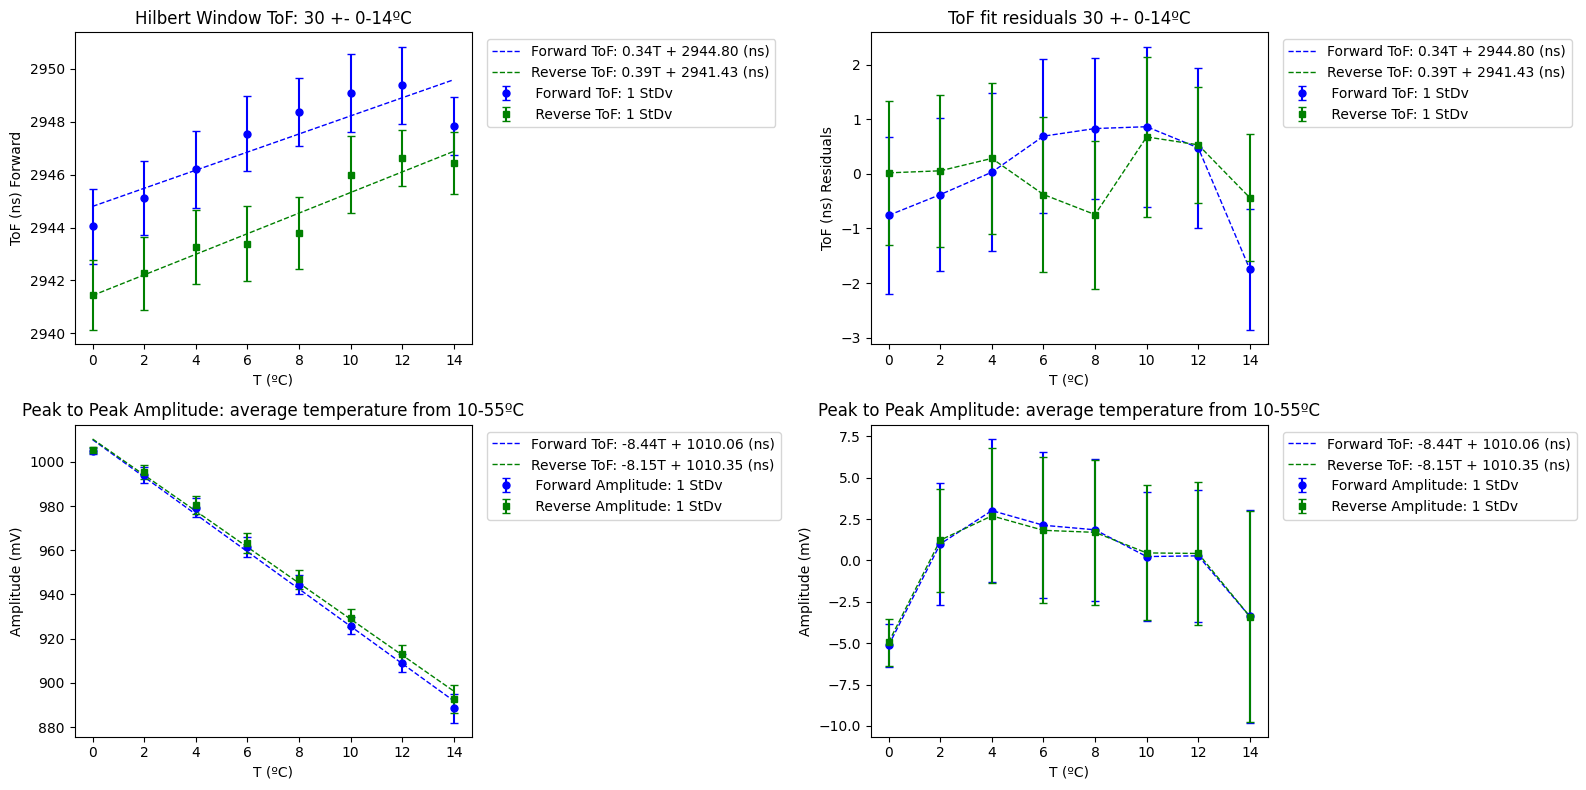

In [16]:
import matplotlib.pyplot as plt

d_temps = range(0, 16, 2)
f_time_arr, f_time_err = [], []
r_time_arr, r_time_err = [], []
f_amp_arr, f_amp_err = [], []
r_amp_arr, r_amp_err = [], []

for i in range(8):
    mask = (
        (merged_filtered_df['3000.1: CH1 Target'] == 30 + i)
        & (merged_filtered_df['3000.2: CH2 Target'] == 30 - i)
        & (merged_filtered_df['2010.1: Output Enable'] == 'ON')
        & (merged_filtered_df['2010.2: Output Enable'] == 'ON')
    )
    filtered_df = merged_filtered_df[mask]
    if filtered_df.empty: 
        print(i)
        continue
    
    f_time_arr.append(filtered_df[f'Hilbert ToF_forward'].mean())
    f_time_err.append(filtered_df[f'Hilbert ToF_forward'].std())

    r_time_arr.append(filtered_df[f'Hilbert ToF_reverse'].mean())
    r_time_err.append(filtered_df[f'Hilbert ToF_reverse'].std())
    
    f_amp_arr.append(filtered_df[f'amplitude_forward'].mean())
    f_amp_err.append(filtered_df[f'amplitude_forward'].std())
    
    r_amp_arr.append(filtered_df[f'amplitude_reverse'].mean())
    r_amp_err.append(filtered_df[f'amplitude_reverse'].std())
    

fig, ax = plt.subplots(2, 2, figsize=(16, 8))

f_m, f_b = np.polyfit(d_temps, f_time_arr, 1)
f_fit = f_m * np.array(d_temps) + f_b
ax[0, 0].plot(d_temps, f_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward ToF: {f_m:.2f}T + {f_b:.2f} (ns)')
ax[0, 0].errorbar(d_temps, f_time_arr, yerr=f_time_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f' Forward ToF: 1 StDv')
r_m, r_b = np.polyfit(d_temps, r_time_arr, 1)
r_fit = r_m * np.array(d_temps) + r_b
ax[0, 0].plot(d_temps, r_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse ToF: {r_m:.2f}T + {r_b:.2f} (ns)')
ax[0, 0].errorbar(d_temps, r_time_arr, yerr=r_time_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f' Reverse ToF: 1 StDv')
ax[0, 0].set_title('Hilbert Window ToF: 30 +- 0-14ºC')
ax[0, 0].set_xlabel('T (ºC)')
ax[0, 0].set_ylabel('ToF (ns) Forward' )
ax[0, 0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

f_residuals = f_time_arr - f_fit
ax[0, 1].plot(d_temps, f_residuals, color='blue', linewidth=1, linestyle='--', label=f'Forward ToF: {f_m:.2f}T + {f_b:.2f} (ns)')
ax[0, 1].errorbar(d_temps, f_residuals, yerr=f_time_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f' Forward ToF: 1 StDv')
r_residuals = r_time_arr - r_fit
ax[0, 1].plot(d_temps, r_residuals, color='green', linewidth=1, linestyle='--', label=f'Reverse ToF: {r_m:.2f}T + {r_b:.2f} (ns)')
ax[0, 1].errorbar(d_temps, r_residuals, yerr=r_time_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f' Reverse ToF: 1 StDv')
ax[0, 1].set_title('ToF fit residuals 30 +- 0-14ºC')
ax[0, 1].set_xlabel('T (ºC)')
ax[0, 1].set_ylabel('ToF (ns) Residuals')
ax[0, 1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

f_m, f_b = np.polyfit(d_temps, f_amp_arr, 1)
f_fit = f_m * np.array(d_temps) + f_b
ax[1,0].plot(d_temps, f_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward ToF: {f_m:.2f}T + {f_b:.2f} (ns)')
ax[1,0].errorbar(d_temps, f_amp_arr, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f' Forward Amplitude: 1 StDv')
r_m, r_b = np.polyfit(d_temps, r_amp_arr, 1)
r_fit = r_m * np.array(d_temps) + r_b
ax[1,0].plot(d_temps, r_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse ToF: {r_m:.2f}T + {r_b:.2f} (ns)')
ax[1,0].errorbar(d_temps, r_amp_arr, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f' Reverse Amplitude: 1 StDv')
ax[1,0].set_title('Peak to Peak Amplitude: average temperature from 10-55ºC')
ax[1,0].set_xlabel('T (ºC)')
ax[1,0].set_ylabel('Amplitude (mV)')
ax[1,0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

f_residuals = f_amp_arr - f_fit
ax[1,1].plot(d_temps, f_residuals, color='blue', linewidth=1, linestyle='--', label=f'Forward ToF: {f_m:.2f}T + {f_b:.2f} (ns)')
ax[1,1].errorbar(d_temps, f_residuals, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f' Forward Amplitude: 1 StDv')
r_residuals = r_amp_arr - r_fit
ax[1,1].plot(d_temps, r_residuals, color='green', linewidth=1, linestyle='--', label=f'Reverse ToF: {r_m:.2f}T + {r_b:.2f} (ns)')
ax[1,1].errorbar(d_temps, r_residuals, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f' Reverse Amplitude: 1 StDv')
ax[1,1].set_title('Peak to Peak Amplitude: average temperature from 10-55ºC')
ax[1,1].set_xlabel('T (ºC)')
ax[1,1].set_ylabel('Amplitude (mV)')
ax[1,1].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

fig.tight_layout()

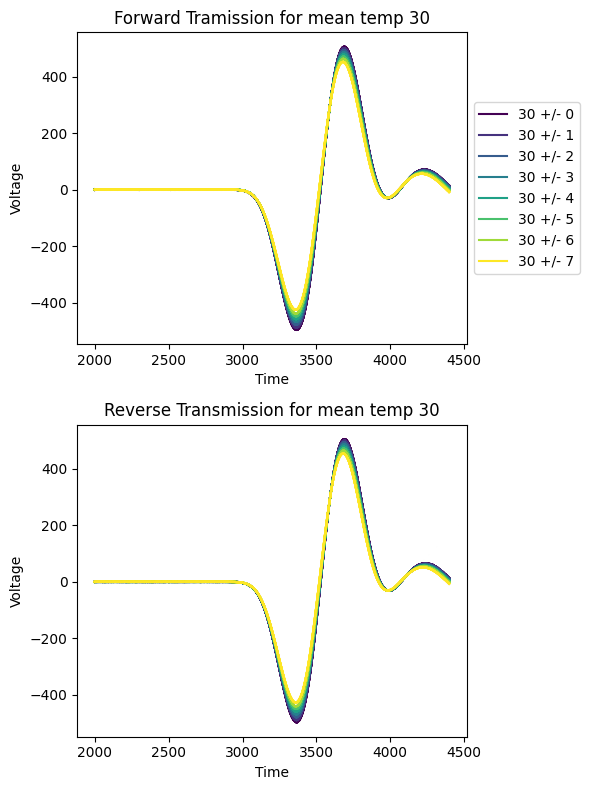

In [17]:
fig, ax = plt.subplots(2, figsize=(6, 8))
for i in range(8):
    mask = (merged_filtered_df['3000.1: CH1 Target'] == 30+i) & \
           (merged_filtered_df['3000.2: CH2 Target'] == 30-i) 
           
    for idx, row in merged_filtered_df.loc[mask].iloc[-10:].iterrows():
        ax[0].plot(
            row['time'][:1200],
            row['voltage_transmission_forward'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
        ax[1].plot(
            row['time'][:1200],
            row['voltage_transmission_reverse'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
    ax[0].set_xlabel('Time')
    ax[0].set_ylabel('Voltage')
    ax[0].set_title(f'Forward Tramission for mean temp 30')
    ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Voltage')
    ax[1].set_title(f'Reverse Transmission for mean temp 30')
    
    fig.tight_layout()